In [1]:
from flip.data_vector.snia_vectors import VelCandleStandardized
from flip.forward.simulation.simulator import return_simulator
from flip.forward.sampler import NutsSampler
import jax_cosmo as jcosmo
import jax.numpy as jnp
import matplotlib.pyplot as plt
from flip.power_spectra import generator
import numpy as np
import os
from pathlib import Path
from flip import data_vector, __flip_dir_path__
import pandas as pd

flip_base = Path(__flip_dir_path__)
data_path = flip_base / "data"
plt.style.use(data_path / "style.mplstyle")

[ 000000.00 ]: 04-23 06:52  root            WARNING  Install GPy to use the gpmatrix emulator


# Parameters assumptions 

In [2]:
h = 0.6766
omega_b = 0.02242
omega_cdm = 0.11933
sigma8_fiducial = 0.8102
n_s = 0.9665

# Generate power spectrum

In [3]:
power_spectrum_engine = "class_engine"

power_spectrum_settings = {
    "h": 0.6766,
    "omega_b": 0.02242,
    "omega_cdm": 0.11933,
    "sigma8": 0.8102,
    "n_s": 0.9665,
}


minimal_wavenumber = 0.0005
maximal_wavenumber = 1.000
number_points = 1000
logspace = True
redshift = 0.0

# Can be changed by "growth_rate" (fsigma_8^fid normalization) or "no_normalization"
# Here, it normalize by sigma_8^fid
normalization_power_spectrum = "growth_amplitude"

# If you want to add non linearity, what model to use
power_spectrum_non_linear_model = "halofit"

# Model used to compute matter and velocity divergence power spectra
power_spectrum_model = "linearbel"

save_path = "./"  # If not None, will save all calculated power spectra in this folder


if os.path.isfile(f"power_spectrum_linearbel_mm_z0.0_kmin0.0005_kmax1.0000_N1000_log.txt"):
    wavenumber, power_spectrum_mm = np.loadtxt("power_spectrum_linearbel_mm_z0.0_kmin0.0005_kmax1.0000_N1000_log.txt")
else:
    (
        wavenumber,
        power_spectrum_mm,
        power_spectrum_mt,
        power_spectrum_tt,
        fiducial,
    ) = generator.compute_power_spectra(
        power_spectrum_engine,
        power_spectrum_settings,
        redshift,
        minimal_wavenumber,
        maximal_wavenumber,
        number_points,
        logspace=logspace,
        normalization_power_spectrum=normalization_power_spectrum,
        power_spectrum_non_linear_model=power_spectrum_non_linear_model,
        power_spectrum_model=power_spectrum_model,
        save_path=save_path,
    )


# Simple test: data from simulator

In [4]:
simulator = return_simulator("gaussian",
                             number_bins = 64, 
                             box_size = 500, 
                             wavenumber = wavenumber, 
                             power_spectrum = power_spectrum_mm, 
                             kmax= 0.1)

parameter_values_dict_true = {"seed": 0,
                             "s8": 0.82,
                             "f": 0.3,
                             "h": 0.7,
                             "b": 0.2}
delta_fourier_true, density_field_true, velocity_field_true = simulator.sample_density_velocity_fields(parameter_values_dict_true)
delta_modes_real_true, delta_modes_imag_true = delta_fourier_true.real[simulator.kmaxindex], delta_fourier_true.imag[simulator.kmaxindex]



In [5]:
def redshift_from_dist_mpch(distance, cosmo=jcosmo.Planck15(), zbins="0:0.5:0.001"):
    redshifts = eval(f"jnp.r_[{zbins}]")
    a = jcosmo.utils.z2a(redshifts)
    cosmo_dist = jcosmo.background.radial_comoving_distance(cosmo=cosmo, a=a)

    return jnp.interp(distance, cosmo_dist, redshifts)


In [6]:

size_sample = 10_000
ra, dec, distance, radial_velocities, target_velocities, target_densities = simulator.draw_targets(
        size_sample,
        parameter_values_dict_true,
        observator=None,
    )

redshift_cosmo = redshift_from_dist_mpch(distance)


cond = distance < 200 #
sigma_nl = 300 #non linearity
vradials = np.random.normal(radial_velocities, sigma_nl)
M=-19.3 #absolute mag
sigma_zi = 50/300000 #error on redshift
sigma_mi = 0.01 #error on mag
mi_simu = np.random.normal(5*np.log10((1+redshift_cosmo)*distance / parameter_values_dict_true["h"])+25+M, sigma_mi)
zi_simu = np.random.normal((1+redshift_cosmo)*(1+radial_velocities/3e5)-1, sigma_zi)

dic={}
dic['ra']=ra[cond]
dic['dec']=dec[cond]
dic['zcos']=zi_simu[cond]

dic['mb']=mi_simu[cond]
dic['e_mb'] = np.full(mi_simu[cond].shape, sigma_mi)
dic['zobs']=zi_simu[cond]
dic['zobs_error']=np.full(zi_simu[cond].shape, 0.0)


In [7]:

data_candle = VelCandleStandardized(data= dic,
                      h = parameter_values_dict_true["h"])

coordinates = jnp.array([ra[cond], dec[cond], distance[cond]])


In [8]:
# Main dict for the fit: define the initial value, the step size and if this is fixed in the sampler or not
# The sampler is adapted to work on any configuration

parameter_dict = {"s8": {"value": 0.82,
                          "step_size" : 0.0001,
                          "fixed" : True,
                         },
                  "sigma_v": {"value": 300.0,
                          "step_size" : 0.0001,
                          "fixed" : True,
                         },
                  "sigma_M": {"value": 0.01,
                          "step_size" : 0.001,
                          "fixed" : True,
                         },
                  "M_0": {"value": -19.3,
                          "step_size": 0.001,
                          "fixed" : True,
                         },
                  "f": {"value": 0.3,
                        "step_size" : 0.001,
                        "fixed" : True,
                         },
                  "h": {"value": 0.7,
                        "step_size" : 0.001,
                          "fixed" : True,
                         },
                  "b": {"value": 0.2,
                        "step_size" : 0.001,
                          "fixed" : True,
                         },
                  "delta_modes_real": {"value": delta_modes_real_true,
                        "step_size" : 30,
                          "fixed" : False,
                         },
                  "delta_modes_imag": {"value": delta_modes_imag_true,
                        "step_size" : 30,
                          "fixed" : False,
                         },
                  "comoving_distance_targets" : {"value": distance[cond],
                          "step_size": 0.01,
                          "fixed" : True,
                         },
                 }


In [9]:
likelihood_type = "candle_grid_gaussian"

nuts_sampler = NutsSampler.init_from_simulator(
        likelihood_type,
        simulator,
        data_candle,
        coordinates,
        parameter_dict,
    )

sampler_states = nuts_sampler.run(num_burnin_steps=0,
                                  mc_steps=40)


num_burnin_steps = 0
mc_steps = 40


/global/common/software/desi/users/adematti/perlmutter/cosmodesiconda/20260321-1.0.0/conda/lib/python3.12/site-packages/jax/_src/ops/scatter.py:104: FutureWarning: scatter inputs have incompatible types: cannot safely cast value from dtype=complex128 to dtype=complex64 with jax_numpy_dtype_promotion=standard. In future JAX releases this will result in an error.
  warnings.warn(
/global/common/software/desi/users/adematti/perlmutter/cosmodesiconda/20260321-1.0.0/conda/lib/python3.12/site-packages/tensorflow_probability/substrates/jax/mcmc/sample.py:339: UserWarning: Tracing all kernel results by default is deprecated. Set the `trace_fn` argument to None (the future default value) or an explicit callback that traces the values you are interested in.
  warnings.warn('Tracing all kernel results by default is deprecated. Set '


In [10]:
chains_parameters = nuts_sampler.return_all_chains_from_states(sampler_states)
average_chains_parameters = nuts_sampler.return_average_chains_from_states(sampler_states, burnin_steps=30)
delta_fourier_sampler, density_field_sampler, velocity_field_sampler = simulator.sample_density_velocity_fields_from_modes(average_chains_parameters)


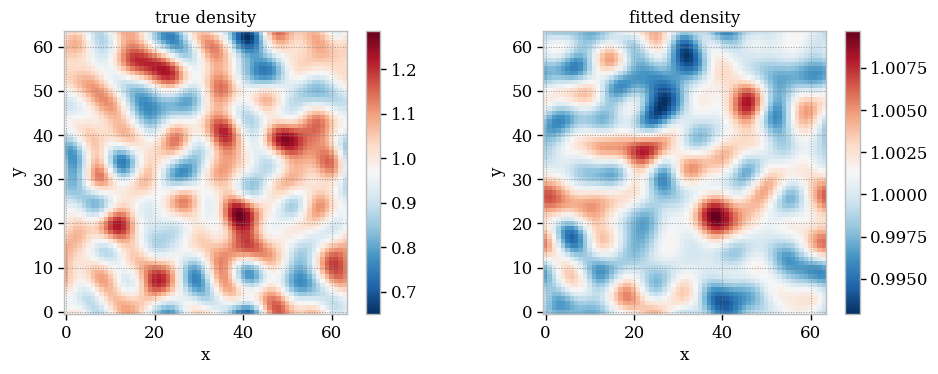

In [11]:
fig, axs = plt.subplots(1,2,figsize=(10,4))
fig.tight_layout(pad=3)
axs[0].set_title('true density')
axs[0].set_xlabel('x')
axs[0].set_ylabel('y')
im0 = axs[0].imshow(density_field_true[...,32].T, cmap = 'RdBu_r', origin ='lower')
fig.colorbar(im0, ax=axs[0], orientation ='vertical')
axs[1].set_title('fitted density')
axs[1].set_xlabel('x')
axs[1].set_ylabel('y')
im1 = axs[1].imshow(density_field_sampler[...,32].T, cmap = 'RdBu_r', origin ='lower')
fig.colorbar(im1, ax=axs[1], orientation ='vertical')


# More complicated: data from simulated SN

In [12]:
simulator = return_simulator("gaussian",
                             number_bins = 64, 
                             box_size = 500, 
                             wavenumber = wavenumber, 
                             power_spectrum = power_spectrum_mm, 
                             kmax= 0.1)


In [13]:
parameter_values_dict_init = {"seed": 0,
                             "s8": 0.82,
                             "f": 0.3,
                             "h": 0.7,
                             "b": 0.2}
delta_fourier_init, density_field_init, velocity_field_init = simulator.sample_density_velocity_fields(parameter_values_dict_init)
delta_modes_real_init, delta_modes_imag_init = delta_fourier_init.real[simulator.kmaxindex], delta_fourier_init.imag[simulator.kmaxindex]


In [14]:
data_velocity = pd.read_parquet(data_path / "data_velocity.parquet")
data_velocity_dict = {}
for k in data_velocity:
    col = np.array(data_velocity[k])
    if col.dtype != object:
        data_velocity_dict[k] = jnp.array(data_velocity[k])

data_candle = VelCandleStandardized(data= data_velocity_dict,
                                   h = parameter_values_dict_init["h"])

coordinates = jnp.array([data_velocity["ra"], 
                         data_velocity["dec"],
                         data_velocity["rcom_zobs"],])


In [15]:
# Main dict for the fit: define the initial value, the step size and if this is fixed in the sampler or not
# The sampler is adapted to work on any configuration

parameter_dict = {"s8": {"value": 0.82,
                          "step_size" : 0.0001,
                          "fixed" : True,
                         },
                  "sigma_v": {"value": 300.0,
                          "step_size" : 0.0001,
                          "fixed" : True,
                         },
                  "sigma_M": {"value": 0.01,
                          "step_size" : 0.001,
                          "fixed" : True,
                         },
                  "M_0": {"value": -19.3,
                          "step_size": 0.001,
                          "fixed" : True,
                         },
                  "f": {"value": 0.3,
                        "step_size" : 0.001,
                        "fixed" : True,
                         },
                  "h": {"value": 0.7,
                        "step_size" : 0.001,
                          "fixed" : True,
                         },
                  "b": {"value": 0.2,
                        "step_size" : 0.001,
                          "fixed" : True,
                         },
                  "delta_modes_real": {"value": delta_modes_real_init,
                        "step_size" : 30,
                          "fixed" : False,
                         },
                  "delta_modes_imag": {"value": delta_modes_imag_init,
                        "step_size" : 30,
                          "fixed" : False,
                         },
                  "comoving_distance_targets" : {"value": jnp.array(data_velocity["rcom_zobs"]),
                          "step_size": 0.01,
                          "fixed" : True,
                         },
                 }


In [16]:
likelihood_type = "candle_grid_gaussian"

nuts_sampler = NutsSampler.init_from_simulator(
        likelihood_type,
        simulator,
        data_candle,
        coordinates,
        parameter_dict,
    )

sampler_states = nuts_sampler.run(num_burnin_steps=0,
                                  mc_steps=40)


num_burnin_steps = 0
mc_steps = 40


/global/common/software/desi/users/adematti/perlmutter/cosmodesiconda/20260321-1.0.0/conda/lib/python3.12/site-packages/jax/_src/ops/scatter.py:104: FutureWarning: scatter inputs have incompatible types: cannot safely cast value from dtype=complex128 to dtype=complex64 with jax_numpy_dtype_promotion=standard. In future JAX releases this will result in an error.
  warnings.warn(
/global/common/software/desi/users/adematti/perlmutter/cosmodesiconda/20260321-1.0.0/conda/lib/python3.12/site-packages/tensorflow_probability/substrates/jax/mcmc/sample.py:339: UserWarning: Tracing all kernel results by default is deprecated. Set the `trace_fn` argument to None (the future default value) or an explicit callback that traces the values you are interested in.
  warnings.warn('Tracing all kernel results by default is deprecated. Set '


In [17]:
chains_parameters = nuts_sampler.return_all_chains_from_states(sampler_states)
average_chains_parameters = nuts_sampler.return_average_chains_from_states(sampler_states, burnin_steps=30)
delta_fourier_sampler, density_field_sampler, velocity_field_sampler = simulator.sample_density_velocity_fields_from_modes(average_chains_parameters)


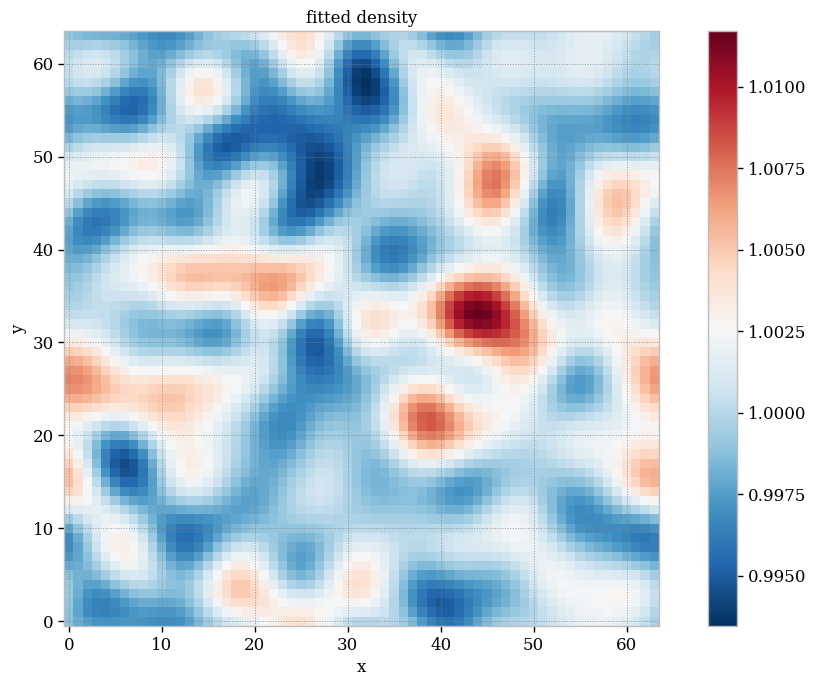

In [18]:
plt.title('fitted density')
plt.xlabel('x')
plt.ylabel('y')
im1 = plt.imshow(density_field_sampler[...,32].T, cmap = 'RdBu_r', origin ='lower')
plt.colorbar(im1, orientation ='vertical')
